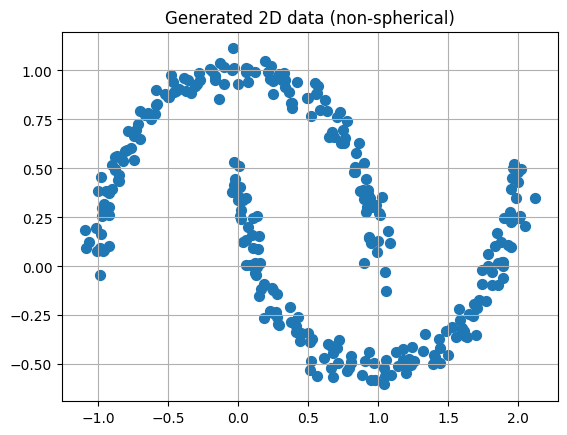

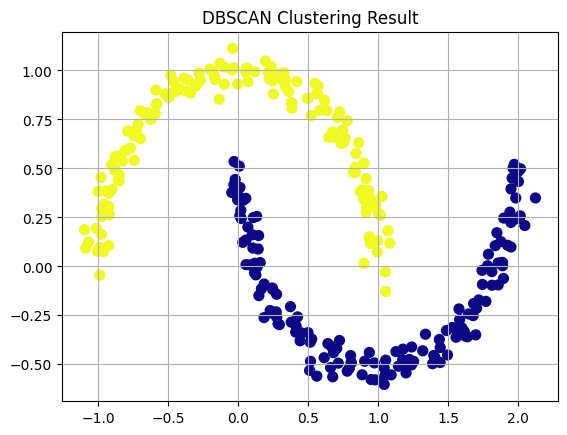

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_moons 
from sklearn.cluster import DBSCAN 
# Generate data 
X, y = make_moons(n_samples=300, noise=0.05, random_state=0) 
# Visualize raw data 
plt.scatter(X[:, 0], X[:, 1], s=50) 
plt.title("Generated 2D data (non-spherical)") 
plt.grid(True) 
plt.show() 
# Apply DBSCAN 
dbscan = DBSCAN(eps=0.2, min_samples=5) 
labels = dbscan.fit_predict(X) 
# Visualize clustering result 
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma', s=50) 
plt.title("DBSCAN Clustering Result") 
plt.grid(True) 
plt.show() 

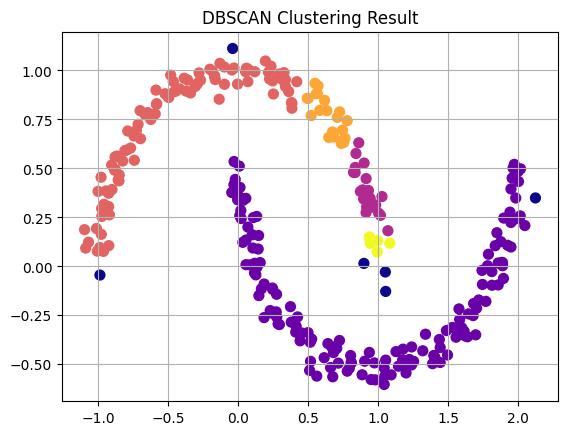

In [4]:
dbscan = DBSCAN(eps=0.1, min_samples=5)  # Try smaller epsilon 
labels = dbscan.fit_predict(X) 
# Visualize clustering result 
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma', s=50) 
plt.title("DBSCAN Clustering Result") 
plt.grid(True) 
plt.show() 

Discussion: 
• What happens when eps is too small or too large?
The clustering is not done correctly. We ended up with more clusters
• What if min_samples is set too low or too high? 
The clustering can be affected
• How does DBSCAN handle noise points?
Sometimes it does not classify them

In [7]:
#small buggy code
from sklearn.cluster import KMeans
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_moons 
# Generate data 
X, y = make_moons(n_samples=300, noise=0.05, random_state=0) 

kmeans = KMeans(n_clusters=2, random_state=0) 
y_kmeans = kmeans.fit_predict(X) 
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', s=50) 
plt.title("K-Means on Non-Spherical Data") 
plt.grid(True) 
plt.show() 

C:\Users\ramse\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


AttributeError: 'NoneType' object has no attribute 'split'

C:\Users\ramse\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\ramse\AppData\Local\Temp\ipykernel_20532\3102118797.py:48: UserWarning: scikit-learn KMeans failed (likely threadpoolctl/OpenBLAS issue). Falling back to NumPy K-Means. Error: 'NoneType' object has no attribute 'split'
  warnings.warn(


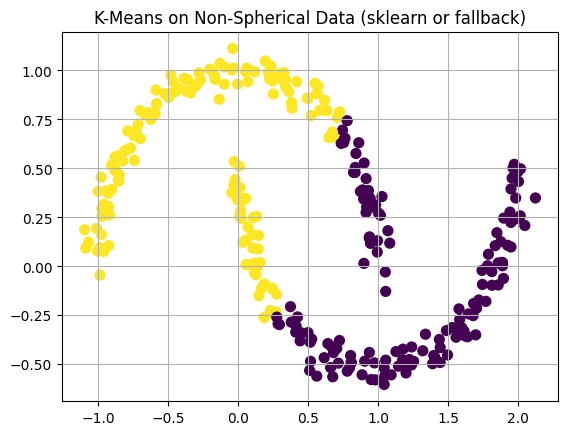

In [8]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import warnings

# Generate data
X, y = make_moons(n_samples=300, noise=0.05, random_state=0)

def fallback_kmeans(X, n_clusters=2, max_iter=300, tol=1e-4, random_state=0):
    """Simple NumPy K-Means fallback (works fine for small datasets)."""
    rng = np.random.default_rng(random_state)
    n_samples, n_features = X.shape
    # initialize centers randomly from samples
    centers = X[rng.choice(n_samples, size=n_clusters, replace=False)].copy()
    labels = np.zeros(n_samples, dtype=int)

    for i in range(max_iter):
        # distances: shape (n_samples, n_clusters)
        dists = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
        new_labels = np.argmin(dists, axis=1)

        # recompute centers; if a cluster is empty, keep previous center
        new_centers = np.vstack(
            [
                X[new_labels == k].mean(axis=0) if np.any(new_labels == k) else centers[k]
                for k in range(n_clusters)
            ]
        )

        # maximum center movement
        shift = np.linalg.norm(new_centers - centers, axis=1).max()
        centers = new_centers
        labels = new_labels

        if shift <= tol:
            break

    return labels, centers

# Try sklearn's KMeans first; if it errors (e.g. threadpoolctl/OpenBLAS bug), use fallback
try:
    kmeans = KMeans(n_clusters=2, random_state=0)
    y_kmeans = kmeans.fit_predict(X)
except AttributeError as e:
    # specific known error from threadpoolctl/OpenBLAS usually raises AttributeError: 'NoneType' object has no attribute 'split'
    warnings.warn(
        "scikit-learn KMeans failed (likely threadpoolctl/OpenBLAS issue). "
        "Falling back to NumPy K-Means. Error: {}".format(e)
    )
    y_kmeans, centers = fallback_kmeans(X, n_clusters=2, random_state=0)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap="viridis", s=50)
plt.title("K-Means on Non-Spherical Data (sklearn or fallback)")
plt.grid(True)
plt.show()

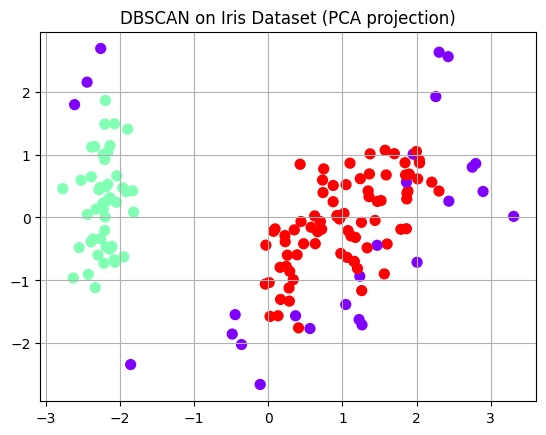

In [6]:
from sklearn.datasets import load_iris 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
# Load and normalize data 
iris = load_iris() 
X = iris.data 
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X) 
# Project to 2D using PCA for visualization 
pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X_scaled) 
# Apply DBSCAN 
dbscan = DBSCAN(eps=0.6, min_samples=5) 
labels = dbscan.fit_predict(X_scaled) 
# Plot clustering result 
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='rainbow', s=50) 
plt.title("DBSCAN on Iris Dataset (PCA projection)") 
plt.grid(True) 
plt.show() 

Part 6: Questions for Discussion 
• What are the advantages of DBSCAN over K-Means?
DBSCAN does not need to initialize with the number of clusters.
• What are limitations of DBSCAN? (e.g., parameter sensitivity, varying densities) 
It is very sensitive to change in the parameters. The density of the  cluster can be very different in some cases.

• Can DBSCAN identify noise in the Iris dataset?
Yes, it can classify them as noise in some cases because their density is lower than the others.
• Would DBSCAN work well in high-dimensional datasets? 
Yes it would work great but the complexity is much higher than Kmeans so it would be much slower.

## Part 7: Going Further 
- Testing DBSCAN on datasets with varying density (e.g., make_blobs with different 
cluster_std). 
- Using Silhouette Score or Adjusted Rand Index to evaluate clustering quality. 
- Trying HDBSCAN, a hierarchical extension of DBSCAN that handles varying densities 
better. 

### Testing DBSCAN on datasets with varying density (e.g., make_blobs with different cluster_std). 

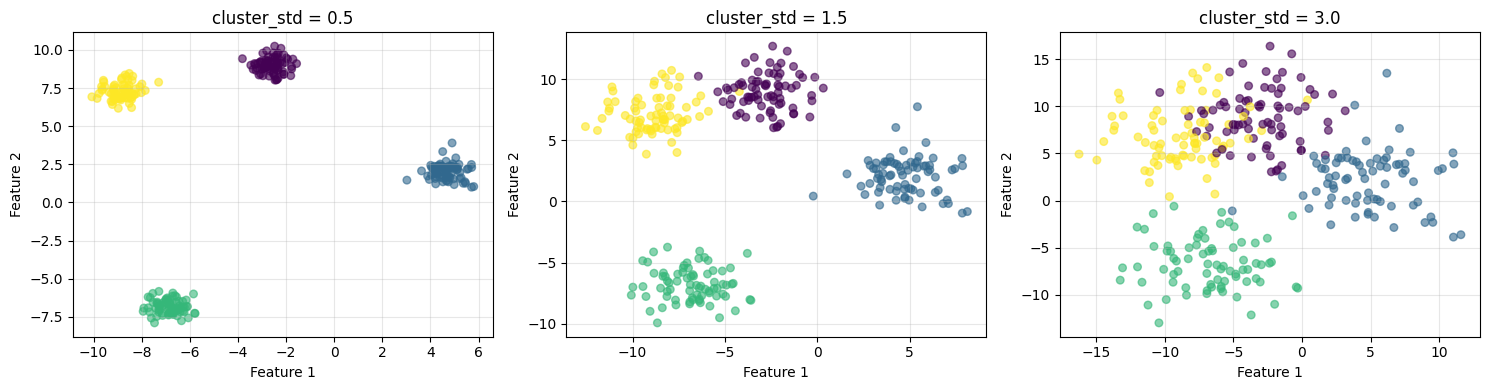

In [6]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Different cluster_std values to compare
std_values = [0.5, 1.5, 3.0]

for idx, std in enumerate(std_values):
    # Generate blob data
    X, y = make_blobs(n_samples=300, centers=4, n_features=2, 
                      cluster_std=std, random_state=42)
    
    # Plot
    axes[idx].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.6, s=30)
    axes[idx].set_title(f'cluster_std = {std}')
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

std_values = [0.5, 1.5, 3.0]

sil_scores = []
ari_scores = []

for std in std_values:
    X, y_true = make_blobs(n_samples=600, centers=4, n_features=2,
                           cluster_std=std, random_state=42)
    # Fit KMeans with the correct number of clusters
    km = KMeans(n_clusters=4, random_state=42, n_init=10)
    y_pred = km.fit_predict(X)

    sil = silhouette_score(X, y_pred)
    ari = adjusted_rand_score(y_true, y_pred)

    sil_scores.append(sil)
    ari_scores.append(ari)

# Plot the metrics versus cluster_std
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(std_values, sil_scores, marker='o')
ax[0].set_title('Silhouette Score vs cluster_std')
ax[0].set_xlabel('cluster_std')
ax[0].set_ylabel('Silhouette Score')
ax[0].set_ylim(-0.1, 1.0)
ax[0].grid(True, alpha=0.3)

ax[1].plot(std_values, ari_scores, marker='o', color='tab:orange')
ax[1].set_title('Adjusted Rand Index vs cluster_std')
ax[1].set_xlabel('cluster_std')
ax[1].set_ylabel('ARI')
ax[1].set_ylim(0.0, 1.05)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

sil_scores, ari_scores

AttributeError: 'NoneType' object has no attribute 'split'

C:\Users\ramse\AppData\Local\Temp\ipykernel_1760\4158987986.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10')
C:\Users\ramse\AppData\Local\Temp\ipykernel_1760\4158987986.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10')
C:\Users\ramse\AppData\Local\Temp\ipykernel_1760\4158987986.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10')


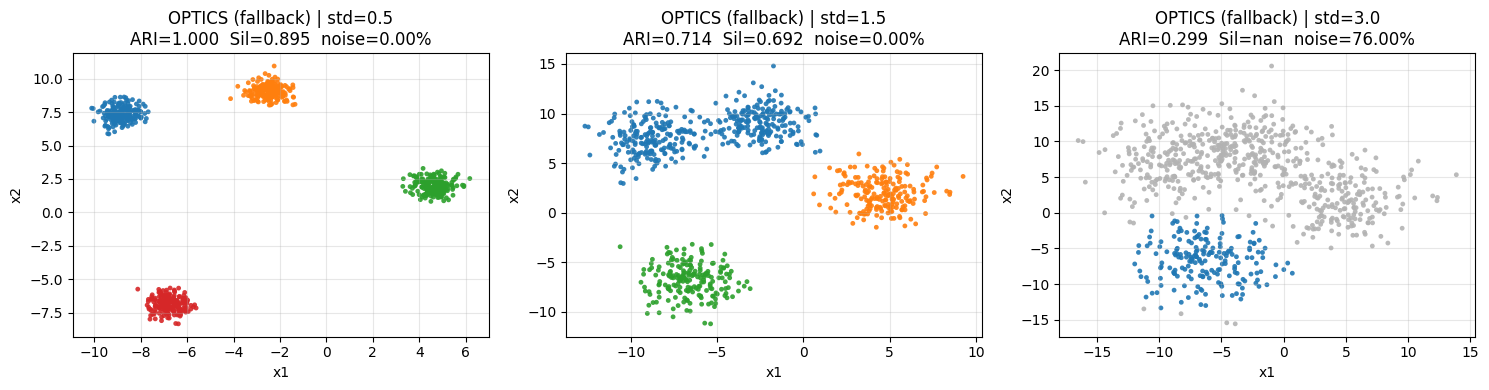

([1.0, 0.7135173897454284, 0.2993880931691883],
 [0.8952467606693122, 0.6924343637797519, nan],
 [0.0, 0.0, 0.76],
 False)

In [9]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score, silhouette_score
import numpy as np

# Try importing hdbscan; if unavailable, fall back to sklearn's OPTICS (similar density-based)
try:
    import hdbscan
    HAS_HDBSCAN = True
except Exception:
    from sklearn.cluster import OPTICS
    HAS_HDBSCAN = False

std_values = [0.5, 1.5, 3.0]

ari_scores = []
sil_scores = []
noise_rates = []

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, std in enumerate(std_values):
    X, y_true = make_blobs(n_samples=800, centers=4, n_features=2,
                           cluster_std=std, random_state=42)
    
    if HAS_HDBSCAN:
        # HDBSCAN automatically finds number of clusters and labels noise as -1
        clusterer = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=10)
        y_pred = clusterer.fit_predict(X)
        title_alg = 'HDBSCAN'
    else:
        # Fallback: OPTICS with xi method to extract clusters, marks noise as -1
        from sklearn.cluster import OPTICS
        optics = OPTICS(min_samples=20, xi=0.05, min_cluster_size=0.05)
        y_pred = optics.fit_predict(X)
        title_alg = 'OPTICS (fallback)'

    # Compute metrics
    unique_labels = np.unique(y_pred)
    noise_rate = np.mean(y_pred == -1)
    noise_rates.append(noise_rate)

    ari = adjusted_rand_score(y_true, y_pred)

    mask = y_pred != -1
    if np.unique(y_pred[mask]).size >= 2 and mask.sum() > 1:
        sil = silhouette_score(X[mask], y_pred[mask])
    else:
        sil = np.nan

    ari_scores.append(ari)
    sil_scores.append(sil)

    # Build an array of colors for each point
    cmap = plt.cm.get_cmap('tab10')
    colors = np.empty((X.shape[0], 4))  # RGBA
    for idx, label in enumerate(y_pred):
        if label == -1:
            colors[idx] = (0.7, 0.7, 0.7, 1.0)  # gray for noise
        else:
            colors[idx] = cmap(label % 10)

    axes[i].scatter(X[:,0], X[:,1], c=colors, s=12, alpha=0.9, linewidths=0)
    axes[i].set_title(f'{title_alg} | std={std}\nARI={ari:.3f}  Sil={sil if not np.isnan(sil) else float("nan"):.3f}  noise={noise_rate:.2%}')
    axes[i].set_xlabel('x1')
    axes[i].set_ylabel('x2')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ari_scores, sil_scores, noise_rates, HAS_HDBSCAN